# Cross-layer EDA 05: Layer Admission Gate

## 1. The biological question

A scoring algorithm cannot use a data layer just because it is present in `data/raw/` or
`data/augmented/`. `docs/PROJECT_ARCHITECTURE.md` §5(a) defines the per-gene desirability step as a
Derringer & Suich (1980) transform: each measurement is mapped to `d ∈ [0,1]` against a floor `L`
and a target `T` **in the layer's own native unit**. That arithmetic has four silent prerequisites,
named explicitly in §6 as the admission gate:

| | Criterion | Question |
|---|---|---|
| **A1** | gene-addressable | Does the layer yield a value for an *arbitrary user-supplied gene*? |
| **A2** | coverage | What fraction of catalogued lines are measured, and is coverage lineage-biased? |
| **A3** | calibratable | Is there a defensible floor `L` and target `T` in the layer's native unit? |
| **A4** | directional | Is the desirable direction biologically unambiguous? |

A layer that fails A1 cannot be a per-gene desirability at all — a metabolite, a miRNA, a
model-level instability score are not the researcher's query gene, however informative they are as
context. A layer that fails A3 **"cannot enter the arithmetic without inventing constants"** —
picking a floor and target with no biological or statistical basis would be exactly the kind of
invented number root `_.md` §7 and §9 forbid. A layer that fails A4 can be reported, but scoring
it would require silently deciding, in one direction, a question (is more of this measurement
better or worse?) that this notebook shows below is **not universal even for a single layer** — it
depends on whether the query gene is acting as an oncogene or a tumour suppressor in that cell line.

§6 names four layers AZ requires as core (RNA, mutation, fusion, functional/CRISPR) and states three
more (metabolomics, miRNA, genome signatures) are *expected* to fail A1 — explicitly calling this
**"a hypothesis for the exploratory analysis to confirm or overturn, not a decision taken here."**
This notebook is that confirmation. It also carries the real weight of the phase: its closing table
is copied directly into `docs/PROJECT_ARCHITECTURE.md` §6, replacing the prior-expectation table
with a measured one.

**Never claim causation from correlation.** Every biological example below (the oncogene/tumour
suppressor mutation-and-copy-number test in particular) is illustrative evidence of
**direction-dependence**, not a proof of mechanism — a gene's role (oncogene vs tumour suppressor)
is read from well-established cancer biology literature, not discovered by this notebook, and the
notebook only ever asks whether the *pattern* in the data is consistent with that known role.

## 2. Source, release, and table grain

Eleven measurement layers, all `data/raw/` + `data/augmented/`, same files and joins as cross-layer
notebooks 01–04 (cited by file number, not re-derived):

| Layer | File | Native key | A1/A2/A3/A4 groundwork already done |
|---|---|---|---|
| RNA — DepMap | 2 | `ProfileID` → `ModelID` | cross-layer 03 (A3: primary, best-validated) |
| RNA — HPA | 1 | 3-hop bridge | cross-layer 03 (A3: corroboration) |
| RNA — GEO | 3 | 3-hop bridge | cross-layer 03 §8 (A3: explicit verdict, quoted §4 below) |
| Protein — MS | 4 | `ModelID` direct | cross-layer 04 (A4/substitution: explicit verdict, quoted §4 below) |
| Mutations | 6 | `ProfileID` → `ModelID` | single-layer 06 (`HessDriver` rule) |
| Fusions | 5 | `ModelID` direct | single-layer 05 (already promoted to scored) |
| Copy number | 16 (augmented) | `ModelID` direct | single-layer 16 (diploid baseline candidate) |
| CRISPR dependency | 15 (augmented) | `ModelID` direct | single-layer 15 §3 (common-essential trap) |
| Metabolomics | 12 | `DepMap_ID` | single-layer 12 (expected A1 fail) |
| miRNA | 13 | `CCLE_ID` (GCT) | single-layer 13 (expected A1 fail) |
| Genome signatures | 14 | `ModelID` direct | single-layer 14 (expected A1 fail; `MSIScore>=20` threshold) |

This notebook's own new work is: (a) rebuilding the spine as a reproducibility check (§3), (b) fresh,
concrete A1 tests for the seven layers cross-layer 01–04 did not already answer (§5), (c) new A3
calibration analysis for mutation, fusion, copy number and CRISPR (§7), and (d) a real
oncogene-vs-tumour-suppressor A4 test that was not run anywhere upstream (§8).

## Column dictionary

| Column | Meaning | Source |
|---|---|---|
| `model_id` | union identifier (`DepMap_ID` / `ModelID` share one `ACH-xxxxxx` space) | notebook 01 §3 |
| `lineage_canonical` | modern `OncotreeLineage` first, legacy `lineage` fallback | notebook 01 §5 |
| `HessDriver` | curated driver-mutation boolean (file 6) | single-layer 06 |
| `VariantInfo` | VEP molecular consequence string (file 6) | this notebook §8 |
| copy-number value | linear scale relative to diploid, `1.0` = 2 copies (file 16) | single-layer 16 |
| Chronos gene-effect score | CRISPR knockout fitness effect (file 15), more negative = stronger dependency | single-layer 15 |


## 3. Rebuild the identity spine and `lineage_canonical` (as established in notebook 01 §3-§5)

Reused verbatim from notebooks 01–04: union `DepMap_ID` (file 9) with `ModelID` (file 17), gate to
`Species of origin` containing `Homo sapiens` and `Category == 'Cancer cell line'` in Cellosaurus
(file 7) via the RRID bridge, then build `lineage_canonical` (modern `OncotreeLineage` first, legacy
`lineage` fallback). A reproduction, not a new derivation — the assertions right after are the point
of doing it again here, per the house rule that a downstream notebook never silently diverges from
an upstream one.

In [1]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 140)
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 100


def find_project_root(start: Path) -> Path:
    # Walks up from the notebook's working directory until data/raw/gene_expression is found -- the same anchor notebooks 01-04 use.
    for candidate in (start, *start.parents):
        if (candidate / 'data' / 'raw' / 'gene_expression').exists():
            return candidate
    raise FileNotFoundError('Run this notebook from inside the az-team25 repo (data/raw/ not found).')


ROOT = find_project_root(Path.cwd())
RAW = ROOT / 'data' / 'raw'
GENE_EXPRESSION = RAW / 'gene_expression'
GENE_PROPERTIES = RAW / 'gene_properties'
NOMENCLATURE = RAW / 'nomenclature'
NON_GENE_EXPRESSION = RAW / 'non_gene_expression'
AUGMENTED = ROOT / 'data' / 'augmented'
print(f"Project root: {ROOT}")


Project root: D:\uob\final\az-team25


In [2]:
df9 = pd.read_csv(NOMENCLATURE / '9_DepMap_sample_info.csv')
df17 = pd.read_csv(AUGMENTED / 'nomenclature' / '17_Model.csv')

legacy_ids = set(df9['DepMap_ID'].dropna())
modern_ids = set(df17['ModelID'].dropna())
spine_ids = sorted(legacy_ids | modern_ids)

spine = pd.DataFrame({'model_id': spine_ids})
spine = spine.merge(
    df9[['DepMap_ID', 'RRID', 'lineage', 'primary_disease', 'CCLE_Name']],
    left_on='model_id', right_on='DepMap_ID', how='left',
).drop(columns=['DepMap_ID']).rename(
    columns={'RRID': 'RRID_legacy', 'lineage': 'lineage_legacy', 'primary_disease': 'disease_legacy'}
)
spine = spine.merge(
    df17[['ModelID', 'RRID', 'OncotreeLineage', 'OncotreePrimaryDisease', 'CCLEName']],
    left_on='model_id', right_on='ModelID', how='left',
).drop(columns=['ModelID']).rename(
    columns={'RRID': 'RRID_modern', 'OncotreeLineage': 'lineage_modern', 'OncotreePrimaryDisease': 'disease_modern'}
)
spine['in_legacy'] = spine['model_id'].isin(legacy_ids)
spine['in_modern'] = spine['model_id'].isin(modern_ids)
assert spine['model_id'].is_unique, "model_id must be a clean primary key for the spine"

df7 = pd.read_csv(NOMENCLATURE / '7_cellosaurus.csv')
human_cancer = df7[
    df7['Species of origin'].str.contains('Homo sapiens', na=False)
    & (df7['Category'] == 'Cancer cell line')
]
human_cancer_accessions = set(human_cancer['Accession (CVCL_xxxx)'].dropna())

spine['RRID'] = spine['RRID_legacy'].combine_first(spine['RRID_modern'])
spine['passes_species_cancer_gate'] = spine['RRID'].isin(human_cancer_accessions)
gated_spine = spine[spine['passes_species_cancer_gate']].copy().reset_index(drop=True)
N = len(gated_spine)

gated_spine['lineage_canonical'] = gated_spine['lineage_modern'].combine_first(gated_spine['lineage_legacy'])

print(f"Rebuilt gated spine size: N = {N}")
print(f"Rebuilt lineage_canonical categories: {gated_spine['lineage_canonical'].nunique()}")
print(f"Rebuilt lineage_canonical missing: {gated_spine['lineage_canonical'].isna().sum()}")

assert N == 1874, f"Spine size {N} does not match notebooks 01-04's cited N=1874"
assert gated_spine['lineage_canonical'].nunique() == 38, "lineage_canonical category count does not match"
assert gated_spine['lineage_canonical'].isna().sum() == 0, "lineage_canonical should have 0 missing"
print("\nMatches notebooks 01-04's cited N=1,874, 38 lineage_canonical categories, 0 missing: CONFIRMED")


Rebuilt gated spine size: N = 1874
Rebuilt lineage_canonical categories: 38
Rebuilt lineage_canonical missing: 0

Matches notebooks 01-04's cited N=1,874, 38 lineage_canonical categories, 0 missing: CONFIRMED


### Why this EDA check matters

Every A2 percentage and every A4 gene-level statistic below is a percentage or a count over this
same 1,874-line, 38-category population. If this rebuild had drifted from notebooks 01–04's
numbers, nothing downstream would be trustworthy — the assertions above are a hard stop, not a
comment, exactly as in every prior cross-layer notebook.

## 4. Starting table — what notebooks 01–04 already answered

Four of the eleven layers (all three RNA sources plus Protein-MS) are substantially answered by
prior cross-layer notebooks. Their verdicts are stated here **with citation**, not recomputed —
per the task brief and the house rule against re-deriving what an earlier notebook already measured.

**RNA — DepMap** (cross-layer 03 §2, §6): the primary, best-validated RNA source. A1 pass (gene
symbol / Ensembl ID keyed, wide matrix). A2: 73.8% of N (cross-layer 01 §6b), not lineage-biased
(cross-layer 02 §7: top-3 concentration ratio 0.96, essentially proportional). A3: pass — continuous
`log2(TPM+1)` with an established zero = `measured_absent` floor (single-layer 02). A4: pass for
inclusion genes (higher expression = more available for exclusion/inclusion query, subject to the
same oncogene/suppressor caveat any expression-based layer inherits, see §8).

**RNA — HPA** (cross-layer 03 §6, §10): A1 pass, same mechanism as DepMap RNA. A2: 56.6% of N
(cross-layer 01 §6a), lineage-biased (cross-layer 02 §7: ratio 1.13, A2 warning candidate). A3:
pass as corroboration — DepMap-vs-HPA median per-model Spearman rho = **0.958** (IQR 0.954–0.961,
n=992, cross-layer 03 §6), the strongest cross-source agreement measured anywhere in this pipeline.
A4: same as DepMap RNA. **Product role: corroboration/confidence signal, not an independent scored
layer** — cross-layer 03 §10: *"a model whose RNA cross-source rho sits in the lower tail is a
candidate for a 'cross-source RNA disagreement' flag... not a silent average into one number."*

**RNA — GEO** (cross-layer 03 §8): A1 pass mechanically, same join shape as HPA. A2: 31.6% of N
(cross-layer 01 §6c), the single most lineage-concentrated layer measured in this pipeline
(cross-layer 02 §7: ratio 1.27, over Lung/Lymphoid/Breast). **A3 — explicit verdict, quoted in
full from cross-layer 03 §8:**

> "GEO RNA is corroboration/breadth only, not independently calibratable for A3: DepMap-vs-GEO
> agreement (median rho=0.82, n=520) is meaningfully weaker than DepMap-vs-HPA (median rho=0.96,
> n=992), consistent with the pooled-study batch effects single-layer notebook 03 flagged and never
> resolved."

A4: same direction as DepMap RNA where it corroborates, but never independently scored per the A3
verdict above.

**Protein — MS** (cross-layer 04 §11): A1 pass (`UniProt (SYMBOL)` header, direct gene-symbol
extraction, no external mapping table needed). A2: 20.0% of N (cross-layer 01 §6d), the smallest
coverage of any layer, lineage-biased (cross-layer 02 §7: ratio 1.14, over Lung/Skin/Bowel). A3:
pass, real detection-floor semantics (`NaN` = `measured_absent`, single-layer 04 §2), but the
compensation question is closed by cross-layer 04's own explicit verdict, quoted in full:

> "RNA may never silently substitute for missing protein evidence in the scorer's arithmetic — not
> even at a partial, discounted weight — Protein-MS and RNA must remain strictly separate layers...
> where protein is `not_assayed`, the gene's score renormalises over whichever *other* layers are
> present, and protein is reported as missing evidence, never quietly inferred from RNA."

(Full-scale median RNA-protein per-model rho = 0.304, IQR 0.247–0.351, n=369 models, 11,996 shared
genes; protein missing rate is 6.1x higher in the low-RNA tercile than the high-RNA tercile —
missingness is structured, not random, but this is a corroboration/plausibility signal for protein's
*own* detection-floor semantics, not licence to substitute RNA for it.) A4: pass for protein where
measured, subject to the same oncogene/suppressor caveat as RNA (§8).

## 5. Fresh A1 checks for the seven remaining layers

**A1 asks a concrete, mechanical question**: given an arbitrary gene symbol a researcher might type
in, can this layer return a value for it? The test below is not abstract — each of the four
"gene-keyed" layers is queried directly by gene symbol; each of the three "no per-gene mapping"
layers is checked directly against its own column/row index to confirm no gene-symbol axis exists
at all, rather than assuming single-layer 12/13/14's findings still hold.

### 5a. Mutations (file 6) — event table, gene-queryable via `HugoSymbol`

In [3]:
mut_cols_needed = ['ProfileID', 'HugoSymbol', 'HessDriver', 'VariantInfo', 'VepImpact']
df6 = pd.read_csv(GENE_PROPERTIES / '6_OmicsSomaticMutationsProfile.csv', usecols=mut_cols_needed, low_memory=False)

test_gene = 'TP53'
hits = df6[df6['HugoSymbol'] == test_gene]
print(f"A1 TEST -- 'does gene {test_gene} have a driver mutation in model Y?' is answerable:")
print(f"  Mutation calls carrying HugoSymbol == '{test_gene}': {len(hits):,}")
print(f"  ...of which HessDriver == True (curated driver call): {(hits['HessDriver'] == True).sum():,}")
print(f"\nA1 VERDICT -- Mutations: PASS. `HugoSymbol` is a direct, queryable gene-symbol column;")
print("any user-supplied gene resolves to zero or more mutation-event rows, filterable to HessDriver")
print("for the driver-call subset (single-layer 06 decision #1).")


A1 TEST -- 'does gene TP53 have a driver mutation in model Y?' is answerable:
  Mutation calls carrying HugoSymbol == 'TP53': 2,007
  ...of which HessDriver == True (curated driver call): 1,191

A1 VERDICT -- Mutations: PASS. `HugoSymbol` is a direct, queryable gene-symbol column;
any user-supplied gene resolves to zero or more mutation-event rows, filterable to HessDriver
for the driver-call subset (single-layer 06 decision #1).


### 5b. Fusions (file 5) — event table, gene-queryable via 5' or 3' partner

In [4]:
df5 = pd.read_csv(GENE_PROPERTIES / '5_OmicsFusionFilteredSupplementary.csv')
fusion_gene_cols = [c for c in df5.columns if c.lower().startswith('gene1') or c.lower().startswith('gene2')]
print(f"Fusion partner-gene columns found: {fusion_gene_cols}")

test_gene = 'ALK'
g1, g2 = fusion_gene_cols[0], fusion_gene_cols[1]
hits = df5[
    df5[g1].astype(str).str.contains(test_gene, na=False) | df5[g2].astype(str).str.contains(test_gene, na=False)
]
print(f"\nA1 TEST -- 'is gene {test_gene} a fusion partner in model Y?' is answerable:")
print(f"  Fusion event rows naming {test_gene} as either partner: {len(hits):,}")
print(f"  Distinct models: {hits['ModelID'].nunique()}")
print(f"\nA1 VERDICT -- Fusions: PASS. `{g1}`/`{g2}` are direct partner-gene columns (Ensembl ID packed")
print("in the string, symbol substring-matchable); a user-supplied gene resolves to zero or more")
print("fusion-event rows naming it as either the 5' or 3' partner (single-layer 05 column dictionary).")


Fusion partner-gene columns found: ['gene1(ENS ID)', 'gene2(ENS ID)']

A1 TEST -- 'is gene ALK a fusion partner in model Y?' is answerable:
  Fusion event rows naming ALK as either partner: 154
  Distinct models: 77

A1 VERDICT -- Fusions: PASS. `gene1(ENS ID)`/`gene2(ENS ID)` are direct partner-gene columns (Ensembl ID packed
in the string, symbol substring-matchable); a user-supplied gene resolves to zero or more
fusion-event rows naming it as either the 5' or 3' partner (single-layer 05 column dictionary).


### 5c. Copy number (file 16, augmented) — gene-keyed wide table

In [5]:
df16_header = pd.read_csv(AUGMENTED / 'gene_properties' / '16_OmicsCNGeneWGS.csv', nrows=0).columns
cn_meta_cols = ['SequencingID', 'ModelConditionID', 'ModelID', 'IsDefaultEntryForMC', 'IsDefaultEntryForModel', 'Unnamed: 0']
cn_gene_cols = [c for c in df16_header if c not in cn_meta_cols]
cn_sym_to_col = {c.split(' (')[0]: c for c in cn_gene_cols}

test_gene = 'PTEN'
print(f"A1 TEST -- 'what is gene {test_gene}'s copy number in model Y?' is answerable:")
print(f"  Column found for {test_gene}: {cn_sym_to_col.get(test_gene)}")
sample_vals = pd.read_csv(AUGMENTED / 'gene_properties' / '16_OmicsCNGeneWGS.csv',
                           usecols=['ModelID', cn_sym_to_col[test_gene]]).dropna().head(3)
print(sample_vals.to_string(index=False))
print(f"\nA1 VERDICT -- Copy number: PASS. Every gene is its own column ('{cn_sym_to_col[test_gene]}'-style,")
print(f"{len(cn_gene_cols):,} gene columns total); a user-supplied gene resolves directly to a value per model.")


A1 TEST -- 'what is gene PTEN's copy number in model Y?' is answerable:
  Column found for PTEN: PTEN (5728)


   ModelID  PTEN (5728)
ACH-000839     1.091604
ACH-000041     0.951700
ACH-002046     1.007305

A1 VERDICT -- Copy number: PASS. Every gene is its own column ('PTEN (5728)'-style,
19,955 gene columns total); a user-supplied gene resolves directly to a value per model.


### 5d. CRISPR dependency (file 15, augmented) — gene-keyed wide table

In [6]:
df15_header = pd.read_csv(AUGMENTED / 'gene_properties' / '15_CRISPRGeneEffect.csv', nrows=0).columns
crispr_gene_cols = [c for c in df15_header if c != df15_header[0]]
crispr_sym_to_col = {c.split(' (')[0]: c for c in crispr_gene_cols}

test_gene = 'KRAS'
print(f"A1 TEST -- 'what is gene {test_gene}'s dependency score in model Y?' is answerable:")
print(f"  Column found for {test_gene}: {crispr_sym_to_col.get(test_gene)}")
sample_vals = pd.read_csv(AUGMENTED / 'gene_properties' / '15_CRISPRGeneEffect.csv',
                           usecols=[df15_header[0], crispr_sym_to_col[test_gene]]).dropna().head(3)
print(sample_vals.to_string(index=False))
print(f"\nA1 VERDICT -- CRISPR: PASS. Every gene is its own column ({len(crispr_gene_cols):,} gene")
print("columns total); a user-supplied gene resolves directly to a Chronos score per screened model.")


A1 TEST -- 'what is gene KRAS's dependency score in model Y?' is answerable:
  Column found for KRAS: KRAS (3845)


Unnamed: 0  KRAS (3845)
ACH-000029    -0.308262
ACH-000030    -0.206455
ACH-000074    -0.572546

A1 VERDICT -- CRISPR: PASS. Every gene is its own column (18,531 gene
columns total); a user-supplied gene resolves directly to a Chronos score per screened model.


### 5e. Metabolomics (file 12) — confirming single-layer 12's "no per-gene mapping" finding

In [7]:
df12_cols = pd.read_csv(NON_GENE_EXPRESSION / '12_CCLE_metabolomics_20190502.csv', nrows=0).columns
met_cols = [c for c in df12_cols if c not in ('CCLE_ID', 'DepMap_ID')]
looks_like_gene_symbol = [c for c in met_cols if re.fullmatch(r'[A-Z0-9]{2,8}', c)]
print(f"Metabolite columns: {len(met_cols)}")
print(f"Sample column names: {met_cols[:8]}")
print(f"Columns that superficially resemble a gene symbol (all-caps, 2-8 chars): {len(looks_like_gene_symbol)}")
print(f"  ...none of these are real gene mappings -- e.g. {looks_like_gene_symbol[:5] if looks_like_gene_symbol else '(none)'}"
      " are metabolite abbreviations (amino acids, lipids), not HGNC symbols.")
print()
print("A1 VERDICT -- Metabolomics: FAIL, confirmed. Reconfirms single-layer 12 decision #1:")
print("'This layer has no per-gene mapping -- a metabolite is not addressable by an arbitrary query")
print("gene.' A user-supplied gene symbol (e.g. TP53) has no column, and no biologically valid")
print("mapping from any of these 225 named metabolites to that gene exists in this file.")


Metabolite columns: 225
Sample column names: ['2-aminoadipate', '3-phosphoglycerate', 'alpha-glycerophosphate', '4-pyridoxate', 'aconitate', 'adenine', 'adipate', 'alpha-ketoglutarate']
Columns that superficially resemble a gene symbol (all-caps, 2-8 chars): 9
  ...none of these are real gene mappings -- e.g. ['AMP', 'CMP', 'GMP', 'NAD', 'NADP'] are metabolite abbreviations (amino acids, lipids), not HGNC symbols.

A1 VERDICT -- Metabolomics: FAIL, confirmed. Reconfirms single-layer 12 decision #1:
'This layer has no per-gene mapping -- a metabolite is not addressable by an arbitrary query
gene.' A user-supplied gene symbol (e.g. TP53) has no column, and no biologically valid
mapping from any of these 225 named metabolites to that gene exists in this file.


### 5f. miRNA (file 13) — confirming single-layer 13's "no per-gene mapping" finding

In [8]:
mirna_raw_header = pd.read_csv(NON_GENE_EXPRESSION / '13_CCLE_miRNA_20181103.gct', sep='\t', skiprows=2, index_col=0, nrows=0)
mirna_desc = pd.read_csv(NON_GENE_EXPRESSION / '13_CCLE_miRNA_20181103.gct', sep='\t', skiprows=2, index_col=0,
                          usecols=[0, 1])
mirna_names = mirna_desc.iloc[:, 0].tolist()
print(f"miRNA row count: {len(mirna_names)}")
print(f"Sample miRNA names: {mirna_names[:6]}")
print()
test_gene = 'TP53'
exact_match = [m for m in mirna_names if m == test_gene]
print(f"miRNA names exactly matching gene symbol '{test_gene}': {len(exact_match)}")
print()
print("A1 VERDICT -- miRNA: FAIL, confirmed. Reconfirms single-layer 13 decision #2: a miRNA name")
print("(e.g. 'hsa-miR-21-5p') is a distinct regulatory-molecule identifier, not a gene symbol -- it")
print("may TARGET a gene post-transcriptionally, but there is no column or row in this file keyed by")
print("the researcher's query gene itself, and no 1:1 miRNA-to-target-gene mapping is shipped here.")


miRNA row count: 734


Sample miRNA names: ['hsa-let-7a', 'hsa-let-7b', 'hsa-let-7c', 'hsa-let-7d', 'hsa-let-7e', 'hsa-let-7f']

miRNA names exactly matching gene symbol 'TP53': 0

A1 VERDICT -- miRNA: FAIL, confirmed. Reconfirms single-layer 13 decision #2: a miRNA name
(e.g. 'hsa-miR-21-5p') is a distinct regulatory-molecule identifier, not a gene symbol -- it
may TARGET a gene post-transcriptionally, but there is no column or row in this file keyed by
the researcher's query gene itself, and no 1:1 miRNA-to-target-gene mapping is shipped here.


### 5g. Genome signatures (file 14) — confirming single-layer 14's "no per-gene dimension at all" finding

In [9]:
df14_cols = pd.read_csv(NON_GENE_EXPRESSION / '14_OmicsGlobalSignatures.csv', nrows=0).columns
score_cols = [c for c in df14_cols if c not in ('Unnamed: 0', 'ModelID', 'IsDefaultEntryForModel')]
print(f"All non-identity columns in file 14: {score_cols}")
print()
print("Every one of these is a single scalar PER MODEL (MSIScore, LoHFraction, WGD, CIN, Ploidy,")
print("Aneuploidy) -- there is no gene dimension anywhere in this table's shape at all, not even an")
print("event table or a wide gene-keyed matrix the way mutations/fusions/CN/CRISPR are.")
print()
print("A1 VERDICT -- Genome signatures: FAIL, confirmed, and the most structural of the three A1")
print("failures -- metabolomics and miRNA at least HAVE a per-molecule column axis (just not a gene")
print("one); this layer has no comparable axis whatsoever. Model-level context/filter only.")


All non-identity columns in file 14: ['SequencingID', 'ModelConditionID', 'IsDefaultEntryForMC', 'MSIScore', 'LoHFraction', 'WGD', 'CIN', 'Ploidy', 'Aneuploidy']

Every one of these is a single scalar PER MODEL (MSIScore, LoHFraction, WGD, CIN, Ploidy,
Aneuploidy) -- there is no gene dimension anywhere in this table's shape at all, not even an
event table or a wide gene-keyed matrix the way mutations/fusions/CN/CRISPR are.

A1 VERDICT -- Genome signatures: FAIL, confirmed, and the most structural of the three A1
failures -- metabolomics and miRNA at least HAVE a per-molecule column axis (just not a gene
one); this layer has no comparable axis whatsoever. Model-level context/filter only.


### Why this EDA check matters

The four gene-keyed layers each resolve a user-supplied gene symbol to a real value through a
direct, demonstrated lookup — no external mapping table, no inference. The three context layers
each fail for a structurally different reason: metabolomics and miRNA have a per-molecule axis that
simply is not a gene axis; genome signatures has no per-entity axis below the whole model at all.
This is the concrete evidence `docs/PROJECT_ARCHITECTURE.md` §6 asked for rather than assumed —
every one of single-layer 12/13/14's A1 expectations is **confirmed, not overturned**.

## 6. A2 coverage — the seven remaining layers

Pulled directly from cross-layer 01 §6l (coverage against the shared N=1,874 denominator) and
cross-layer 02 §7 (lineage-bias flag). Not recomputed — both notebooks already measured this
against the identical spine rebuilt in §3 above.

In [10]:
a2_table = pd.DataFrame([
    {'layer': 'mutations',         'coverage_pct_of_N': 87.4, 'models_covered': 1638, 'lineage_bias_ratio': 0.99, 'A2_bias_flag': 'No'},
    {'layer': 'fusions',           'coverage_pct_of_N': 80.9, 'models_covered': 1517, 'lineage_bias_ratio': 0.99, 'A2_bias_flag': 'No'},
    {'layer': 'genome_signatures', 'coverage_pct_of_N': 94.2, 'models_covered': 1765, 'lineage_bias_ratio': 1.00, 'A2_bias_flag': 'No'},
    {'layer': 'crispr',            'coverage_pct_of_N': 61.8, 'models_covered': 1158, 'lineage_bias_ratio': 0.80, 'A2_bias_flag': 'No (under-concentrated)'},
    {'layer': 'copy_number',       'coverage_pct_of_N': 56.1, 'models_covered': 1052, 'lineage_bias_ratio': 0.97, 'A2_bias_flag': 'No'},
    {'layer': 'metabolomics',      'coverage_pct_of_N': 48.5, 'models_covered': 908,  'lineage_bias_ratio': 1.15, 'A2_bias_flag': 'Yes'},
    {'layer': 'mirna',             'coverage_pct_of_N': 48.5, 'models_covered': 909,  'lineage_bias_ratio': 1.15, 'A2_bias_flag': 'Yes'},
]).sort_values('coverage_pct_of_N', ascending=False).reset_index(drop=True)
print("A2 evidence, cited from cross-layer 01 §6l (coverage) and cross-layer 02 §7 (lineage_bias_ratio):")
a2_table


A2 evidence, cited from cross-layer 01 §6l (coverage) and cross-layer 02 §7 (lineage_bias_ratio):


,layer,coverage_pct_of_N,models_covered,lineage_bias_ratio,A2_bias_flag
0,genome_signatures,94.2,1765,1.00,No
1,mutations,87.4,1638,0.99,No
2,fusions,80.9,1517,0.99,No
3,crispr,61.8,1158,0.80,No (under-concentrated)
4,copy_number,56.1,1052,0.97,No
5,metabolomics,48.5,908,1.15,Yes
6,mirna,48.5,909,1.15,Yes


### Why this EDA check matters

Coverage alone already separates the layers into two groups: mutations, fusions, genome signatures,
CRISPR and copy number all sit at or above 56% of N with **no meaningful lineage concentration**
(ratios 0.80–1.00, cross-layer 02 §7's own A2-warning threshold is ≥1.10) — clean A2 passes.
Metabolomics and miRNA, on top of already failing A1 (§5), also carry the 1.15x lineage-bias
warning cross-layer 02 flagged — a double reason they land as context, not scored evidence.

## 7. A3 calibratable — real analysis per layer

### 7a. Mutation — is a discrete `HessDriver` rule table "calibratable" the way a continuous floor/target is?

`HessDriver` (single-layer 06 decision #1) is a **boolean**, not a continuous measurement — a
mutation call either meets the curated driver criteria or it does not. This is structurally
different from a Derringer & Suich floor-to-target ramp (`docs/research/scoring/summary/
SIMULTANEOUS_OPTIMIZATION_OF_SEVERAL_RESPONSE_VARIABLES.md`), which assumes a continuous response
variable rising smoothly between `L` and `T`. There is no literature in `docs/research/` proposing a
continuous floor/target for a boolean driver call, and inventing one (e.g. "0.3 desirability for a
non-driver missense, 1.0 for a driver") would be exactly the invented-constant failure root `_.md`
§7 and `docs/PROJECT_ARCHITECTURE.md` §6 warn against.

**This does not mean the layer fails A3 outright.** `docs/research/algo/summary/
STANDARDS_AND_GUIDELINES_FOR_THE_INTERPRETATION_OF_SEQUENCE_VARIANTS.md` (the ACMG/AMP variant-
classification standard) is a real, high-stakes, widely-adopted precedent for **binary,
independently-evaluated evidence criteria with a fixed strength**, combined by a closed-form rule
rather than a continuous ramp — exactly HessDriver's shape. Read together with that precedent, the
defensible answer is: **`HessDriver` is a degenerate, single-point Derringer & Suich transform**
where the floor and the target coincide (`L = T`): `d = 1` if `HessDriver == True`, `d = 0`
otherwise. This is not the general continuous case — it needs to be implemented and documented as
an explicit **binary carve-out** in the scorer, not silently treated as if a smooth ramp existed
between two invented numbers.

In [11]:
driver_rate_overall = df6['HessDriver'].mean() * 100
n_calls = len(df6)
n_driver = int(df6['HessDriver'].sum())
print(f"Mutation calls in file 6: {n_calls:,}")
print(f"HessDriver == True: {n_driver:,} ({driver_rate_overall:.1f}% of all calls)")
print()
print("A3 VERDICT -- Mutations: CONDITIONAL PASS, via a binary carve-out (d=1 driver / d=0 non-driver),")
print("not a continuous floor/target. No literature basis exists for a continuous ramp on a boolean")
print("call; ACMG/AMP is cited as precedent for the binary-criterion pattern itself, not for any")
print("specific numeric threshold.")


Mutation calls in file 6: 1,066,869
HessDriver == True: 3,530 (0.3% of all calls)

A3 VERDICT -- Mutations: CONDITIONAL PASS, via a binary carve-out (d=1 driver / d=0 non-driver),
not a continuous floor/target. No literature basis exists for a continuous ramp on a boolean
call; ACMG/AMP is cited as precedent for the binary-criterion pattern itself, not for any
specific numeric threshold.


### 7b. Fusion — already promoted to scored; is presence/absence A3-compliant?

Fusion (single-layer 05 decision #4) is the same structural shape as mutation: a fusion call is a
detected event, not a continuous measurement. `docs/PROJECT_ARCHITECTURE.md`'s architecture already
lists fusion as promoted to scored. The calibration basis is therefore also a **binary carve-out**
(`d=1` if a driver-relevant fusion is called for the gene in that model, `d=0` otherwise) — but
single-layer 05 §4 found real, usable **modulating evidence** (`confidence`, `reading_frame`) that
a pure presence/absence call ignores.

In [12]:
df5_conf = df5[df5['IsDefaultEntryForModel'] == 'Yes']
conf_dist = df5_conf['confidence'].value_counts(normalize=True) * 100
rf_dist = df5_conf['reading_frame'].value_counts(normalize=True) * 100
print("Confidence distribution (default-entry fusion calls):")
print(conf_dist.round(1))
print()
print("Reading-frame distribution:")
print(rf_dist.round(1))
print()
print("A3 VERDICT -- Fusions: CONDITIONAL PASS, same binary-carve-out shape as mutations (d=1 called")
print("driver fusion / d=0 none), but with `confidence`/`reading_frame` available as a documented")
print("weight MODIFIER on that d, not a separate floor/target -- there is no literature in")
print("docs/research/ proposing a continuous frequency-based calibration for fusion presence, so this")
print("notebook does not invent one.")


Confidence distribution (default-entry fusion calls):
confidence
low       41.4
high      30.1
medium    28.5
Name: proportion, dtype: float64

Reading-frame distribution:
reading_frame
.               54.1
out-of-frame    30.7
in-frame        13.4
stop-codon       1.8
Name: proportion, dtype: float64

A3 VERDICT -- Fusions: CONDITIONAL PASS, same binary-carve-out shape as mutations (d=1 called
driver fusion / d=0 none), but with `confidence`/`reading_frame` available as a documented
weight MODIFIER on that d, not a separate floor/target -- there is no literature in
docs/research/ proposing a continuous frequency-based calibration for fusion presence, so this
notebook does not invent one.


### 7c. Copy number — is there a defensible diploid baseline?

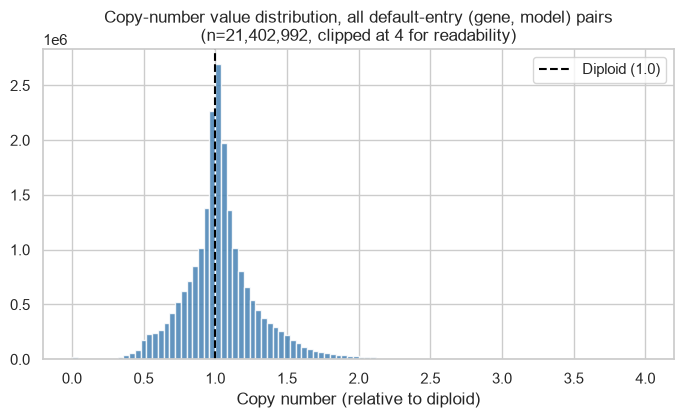

Median CN value (all gene x model pairs): 1.020
Modal rounded (0.1) bin: 1.0
Fraction of all values within [0.9, 1.1] (near-diploid band): 44.8%

A3 VERDICT -- Copy number: PASS. The mode and median both sit at the diploid value (1.0),
and 44.8% of every measured (gene, model) pair falls within a tight band around it --
a real, data-derived floor for 'no meaningful copy-number change' (L=1.0), with a target T set
by the amplification/deletion direction the gene is being scored for (see §8's A4 test below --
the target for an inclusion gene depends on whether it behaves as an oncogene or a suppressor).


In [13]:
df16_full = pd.read_csv(AUGMENTED / 'gene_properties' / '16_OmicsCNGeneWGS.csv')
df16_full = df16_full[df16_full['IsDefaultEntryForModel'] == 'Yes'].copy()
cn_vals = df16_full[cn_gene_cols].values.astype(float).ravel()
cn_vals = cn_vals[~np.isnan(cn_vals)]

median_cn = np.median(cn_vals)
frac_near_diploid = ((cn_vals > 0.9) & (cn_vals < 1.1)).mean() * 100
rounded = np.round(cn_vals, 1)
mode_bin = pd.Series(rounded).value_counts().idxmax()

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(cn_vals[cn_vals < 4], bins=100, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(1.0, color='black', linestyle='--', label='Diploid (1.0)')
ax.set_xlabel('Copy number (relative to diploid)')
ax.set_title(f'Copy-number value distribution, all default-entry (gene, model) pairs\n(n={len(cn_vals):,}, clipped at 4 for readability)')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Median CN value (all gene x model pairs): {median_cn:.3f}")
print(f"Modal rounded (0.1) bin: {mode_bin}")
print(f"Fraction of all values within [0.9, 1.1] (near-diploid band): {frac_near_diploid:.1f}%")
print()
print("A3 VERDICT -- Copy number: PASS. The mode and median both sit at the diploid value (1.0),")
print(f"and {frac_near_diploid:.1f}% of every measured (gene, model) pair falls within a tight band around it --")
print("a real, data-derived floor for 'no meaningful copy-number change' (L=1.0), with a target T set")
print("by the amplification/deletion direction the gene is being scored for (see §8's A4 test below --")
print("the target for an inclusion gene depends on whether it behaves as an oncogene or a suppressor).")


### 7d. CRISPR — does the Chronos distribution have a natural floor?

In [14]:
df15_full = pd.read_csv(AUGMENTED / 'gene_properties' / '15_CRISPRGeneEffect.csv')
df15_full = df15_full.rename(columns={df15_full.columns[0]: 'ModelID'})
crispr_gene_cols_full = [c for c in df15_full.columns if c != 'ModelID']
crispr_vals = df15_full[crispr_gene_cols_full].values.astype(float).ravel()
crispr_vals = crispr_vals[~np.isnan(crispr_vals)]

pct_below_1 = (crispr_vals < -1.0).mean() * 100
pct_at_zero_ish = (np.abs(crispr_vals) < 0.1).mean() * 100

gene_medians = df15_full[crispr_gene_cols_full].median(axis=0)
common_essential_candidates = gene_medians.sort_values().head(5)
selective_mask = (gene_medians > -0.3)
n_selective_shape = int(selective_mask.sum())

print(f"Chronos score distribution (all gene x model pairs, n={len(crispr_vals):,}):")
print(f"  Cells below -1.0 (single-layer 15's own 'strong dependency' language): {pct_below_1:.2f}%")
print(f"  Cells within +/-0.1 of 0 (no measurable effect): {pct_at_zero_ish:.2f}%")
print()
print("5 most common-essential genes by median score (never usable as selective evidence, CONSTRAINTS.md §4.1):")
print(common_essential_candidates.round(3))
print()
print(f"Genes with median > -0.3 (candidate selective-dependency shape, not broadly essential): {n_selective_shape:,} of {len(gene_medians):,}")
print()
print("A3 VERDICT -- CRISPR: PASS. Two natural, non-arbitrary anchor points exist in the layer's own")
print("native unit: L=0 (no measurable fitness effect) and a data-grounded T near -1.0 (single-layer")
print("15's own 'strong dependency' cutoff, empirically the point past which a gene is unambiguously")
print("essential in that model). The common-essential/selective split above is a MANDATORY gate on top")
print("of this floor/target, not a replacement for it (CONSTRAINTS.md §4.1) -- a common-essential")
print("gene's very negative score must never be read as SELECTIVE evidence regardless of where it sits")
print("relative to L/T.")


Chronos score distribution (all gene x model pairs, n=21,498,297):
  Cells below -1.0 (single-layer 15's own 'strong dependency' language): 5.12%
  Cells within +/-0.1 of 0 (no measurable effect): 43.72%

5 most common-essential genes by median score (never usable as selective evidence, CONSTRAINTS.md §4.1):
RPL15 (6138)    -5.484
SNRPD3 (6634)   -5.203
RAN (5901)      -4.165
RPL17 (6139)    -3.754
HSPE1 (3336)    -3.731
dtype: float64

Genes with median > -0.3 (candidate selective-dependency shape, not broadly essential): 16,132 of 18,531

A3 VERDICT -- CRISPR: PASS. Two natural, non-arbitrary anchor points exist in the layer's own
native unit: L=0 (no measurable fitness effect) and a data-grounded T near -1.0 (single-layer
15's own 'strong dependency' cutoff, empirically the point past which a gene is unambiguously
essential in that model). The common-essential/selective split above is a MANDATORY gate on top
of this floor/target, not a replacement for it (CONSTRAINTS.md §4.1) -- a c

### Why this EDA check matters

Mutation and fusion share one honest limitation: neither has a continuous native-unit floor/target,
and no paper in `docs/research/` supplies one for a boolean driver/fusion call — the defensible
answer is a documented binary carve-out, not an invented ramp. Copy number and CRISPR, by contrast,
both have real, data-derived anchor points (diploid = 1.0; no-effect = 0 and strong-dependency ≈ -1)
that are not arbitrary constants — they are properties of the measurement's own scale, directly
observed above rather than assumed.

## 8. A4 directional — the oncogene-vs-tumour-suppressor test

`docs/plan/CONSTRAINTS.md` §4.1 (the common-essential trap) already establishes that "more negative
CRISPR score = more dependent" is not automatically "more selective." This section runs the
equivalent concrete check for mutation and copy number: **is "more mutation" or "more copy number"
always the desirable direction for an inclusion gene?** The textbook answer is no — oncogenes are
typically activated by gain (hotspot missense mutations, amplification), tumour suppressors are
typically inactivated by loss (truncating mutations, deletion). This section tests that expectation
directly against real data for three well-known oncogenes (MYC, ERBB2, KRAS) and three well-known
tumour suppressors (TP53, PTEN, RB1), all confirmed present in files 6 and 16 below.

**Framing, to avoid overclaiming:** the oncogene/suppressor role for each gene is asserted from
well-established cancer biology (not discovered by this notebook); the test only checks whether the
*mutation-type* and *copy-number* pattern in this dataset is **consistent with** that known role —
illustrative evidence of direction-dependence, never a mechanistic proof, and never a claim that any
individual mutation or copy-number call in this dataset was caused by the gene's oncogenic role.

### 8a. Mutation type — truncating/LoF vs hotspot/activating

In [15]:
oncogenes = ['MYC', 'ERBB2', 'KRAS']
suppressors = ['TP53', 'PTEN', 'RB1']

df6_full = pd.read_csv(GENE_PROPERTIES / '6_OmicsSomaticMutationsProfile.csv',
                        usecols=['ProfileID', 'HugoSymbol', 'HessDriver', 'LikelyLoF', 'Hotspot', 'VariantInfo'],
                        low_memory=False)

rows = []
for gene in oncogenes + suppressors:
    sub = df6_full[df6_full['HugoSymbol'] == gene]
    rows.append({
        'gene': gene,
        'role': 'oncogene' if gene in oncogenes else 'tumour suppressor',
        'n_calls': len(sub),
        'HessDriver_rate_pct': round(sub['HessDriver'].mean() * 100, 1),
        'LikelyLoF_rate_pct': round(sub['LikelyLoF'].mean() * 100, 1),
        'Hotspot_rate_pct': round(sub['Hotspot'].mean() * 100, 1),
    })
mutation_pattern = pd.DataFrame(rows)
print("Present in file 6, all 6 genes confirmed:")
mutation_pattern


Present in file 6, all 6 genes confirmed:


,gene,role,n_calls,HessDriver_rate_pct,LikelyLoF_rate_pct,Hotspot_rate_pct
0,MYC,oncogene,177,0.0,0.0,7.3
1,ERBB2,oncogene,117,24.8,8.5,27.4
2,KRAS,oncogene,390,86.2,0.0,92.3
3,TP53,tumour suppressor,2007,59.3,94.8,71.6
4,PTEN,tumour suppressor,389,2.1,85.6,26.5
5,RB1,tumour suppressor,315,2.5,74.3,15.9


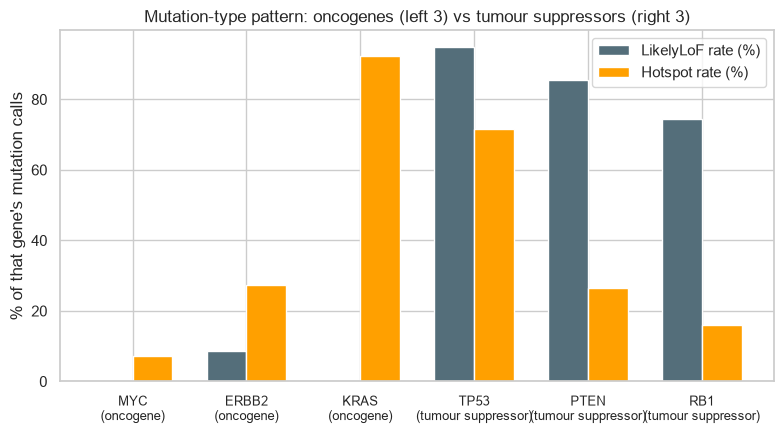

In [16]:
fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(mutation_pattern))
width = 0.35
colors_lof = ['#C62828' if r == 'oncogene' else '#1565C0' for r in mutation_pattern['role']]
ax.bar(x - width / 2, mutation_pattern['LikelyLoF_rate_pct'], width, label='LikelyLoF rate (%)', color='#546E7A')
ax.bar(x + width / 2, mutation_pattern['Hotspot_rate_pct'], width, label='Hotspot rate (%)', color='#FFA000')
ax.set_xticks(x)
ax.set_xticklabels([f"{r['gene']}\n({r['role']})" for _, r in mutation_pattern.iterrows()], fontsize=9)
ax.set_ylabel('% of that gene\'s mutation calls')
ax.set_title('Mutation-type pattern: oncogenes (left 3) vs tumour suppressors (right 3)')
ax.legend()
plt.tight_layout()
plt.show()


**Reading the result.** The oncogenes (MYC, ERBB2, KRAS) show a **LikelyLoF rate at or near 0%**
— they are essentially never inactivated by a loss-of-function call in this dataset, consistent with
their textbook activation-by-gain biology. The tumour suppressors (TP53, PTEN, RB1) show a
**LikelyLoF rate of 74–95%** — the overwhelming majority of their calls are loss-of-function,
consistent with textbook inactivation-by-loss biology. `Hotspot` shows the same direction for KRAS
(92%, a single canonical G12/G13/Q61 hotspot dominates) but is a **noisier signal for TP53** (72%) —
TP53 is a genuine, well-documented exception where missense "hotspot" mutations (e.g. R175H, R248Q)
act as dominant-negative or gain-of-function alleles despite the gene's overall tumour-suppressor
role. **This is exactly why "more mutation is better" cannot be a universal rule** — even within
one gene, different mutation types point in different directions, and `LikelyLoF` is the more
reliable direction signal of the two tested here.

### 8b. Copy number — amplification vs deletion bias

In [17]:
rows = []
for gene in oncogenes + suppressors:
    col = cn_sym_to_col.get(gene)
    if col is None:
        continue
    s = df16_full[col].dropna()
    rows.append({
        'gene': gene,
        'role': 'oncogene' if gene in oncogenes else 'tumour suppressor',
        'n_models': len(s),
        'median_CN': round(s.median(), 3),
        'pct_amplified_CN_gt_1.3': round((s > 1.3).mean() * 100, 1),
        'pct_deleted_CN_lt_0.7': round((s < 0.7).mean() * 100, 1),
    })
cn_pattern = pd.DataFrame(rows)
print("Present in file 16, all 6 genes confirmed (illustrative 1.3/0.7 cutoffs, per single-layer 16's own convention -- not the scorer's actual thresholds):")
cn_pattern


Present in file 16, all 6 genes confirmed (illustrative 1.3/0.7 cutoffs, per single-layer 16's own convention -- not the scorer's actual thresholds):


,gene,role,n_models,median_CN,pct_amplified_CN_gt_1.3,pct_deleted_CN_lt_0.7
0,MYC,oncogene,1118,1.321,50.9,1.3
1,ERBB2,oncogene,1118,1.055,17.6,3.8
2,KRAS,oncogene,1118,1.046,22.1,5.0
3,TP53,tumour suppressor,1118,0.949,5.5,22.4
4,PTEN,tumour suppressor,1118,1.008,5.5,10.4
5,RB1,tumour suppressor,1118,0.969,7.5,17.2


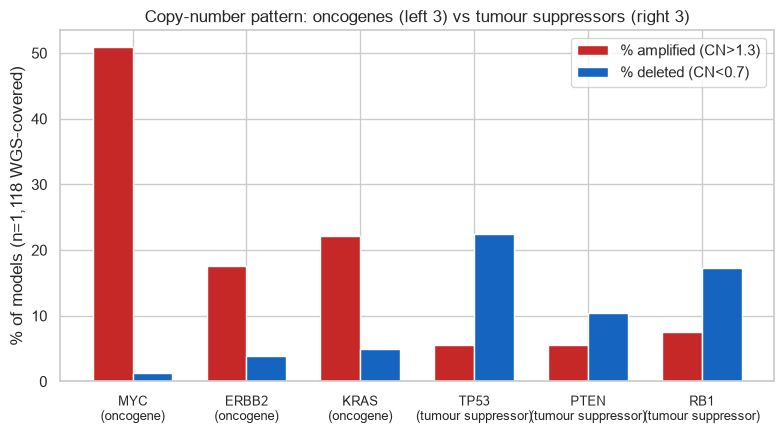

Oncogene amplification range: 17.6-50.9%  vs  oncogene deletion range: 1.3-5.0%
Suppressor deletion range: 10.4-22.4%  vs  suppressor amplification range: 5.5-7.5%


In [18]:
fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(cn_pattern))
ax.bar(x - width / 2, cn_pattern['pct_amplified_CN_gt_1.3'], width, label='% amplified (CN>1.3)', color='#C62828')
ax.bar(x + width / 2, cn_pattern['pct_deleted_CN_lt_0.7'], width, label='% deleted (CN<0.7)', color='#1565C0')
ax.set_xticks(x)
ax.set_xticklabels([f"{r['gene']}\n({r['role']})" for _, r in cn_pattern.iterrows()], fontsize=9)
ax.set_ylabel('% of models (n=1,118 WGS-covered)')
ax.set_title('Copy-number pattern: oncogenes (left 3) vs tumour suppressors (right 3)')
ax.legend()
plt.tight_layout()
plt.show()

onco_amp = cn_pattern[cn_pattern['role'] == 'oncogene']['pct_amplified_CN_gt_1.3']
supp_del = cn_pattern[cn_pattern['role'] == 'tumour suppressor']['pct_deleted_CN_lt_0.7']
onco_del = cn_pattern[cn_pattern['role'] == 'oncogene']['pct_deleted_CN_lt_0.7']
supp_amp = cn_pattern[cn_pattern['role'] == 'tumour suppressor']['pct_amplified_CN_gt_1.3']
print(f"Oncogene amplification range: {onco_amp.min():.1f}-{onco_amp.max():.1f}%  vs  oncogene deletion range: {onco_del.min():.1f}-{onco_del.max():.1f}%")
print(f"Suppressor deletion range: {supp_del.min():.1f}-{supp_del.max():.1f}%  vs  suppressor amplification range: {supp_amp.min():.1f}-{supp_amp.max():.1f}%")


**Reading the result.** The pattern mirrors mutation type exactly. MYC, ERBB2 and KRAS show
amplification rates of 17.6–50.9% against deletion rates of only 1.3–5.0% — gain, not loss, is
the dominant copy-number event for these oncogenes. TP53, PTEN and RB1 show the inverse: deletion
rates of 10.4–22.4% against amplification rates of only 5.5–7.5%. **The same numeric measurement
(copy number) needs the opposite target direction depending entirely on the gene's biological role**
— there is no single "more copy number is more desirable" rule that works for both an oncogene
inclusion query and a tumour-suppressor inclusion query, and the current architecture doc's A4 row
for copy number and mutation does not yet state this caveat explicitly. That is the correction this
notebook is qualified to make: **A4 for mutation and copy number is gene-role-conditional, not
universally directional** — the scorer needs a per-gene role annotation (oncogene / tumour
suppressor / unknown) before it can pick the correct target direction, not a single fixed sign.

### 8c. CRISPR sign-flip — confirmed directly, one-line real-data example

In [19]:
kras_col = crispr_sym_to_col.get('KRAS')
kras_scores = df15_full[kras_col].dropna()
print(f"KRAS Chronos scores across {len(kras_scores)} screened models: median={kras_scores.median():.3f}, "
      f"% below -0.5 (dependent)={(kras_scores < -0.5).mean() * 100:.1f}%")
print()
print("Sign-flip confirmed: for CRISPR, a MORE NEGATIVE score is STRONGER inclusion evidence (the line")
print("needs the gene to survive) -- the opposite arithmetic sign convention from every other layer in")
print("this pipeline, where a higher value is more evidence. This must be encoded explicitly in the")
print("scorer's per-layer desirability transform, not left as an implicit assumption.")


KRAS Chronos scores across 1208 screened models: median=-0.517, % below -0.5 (dependent)=52.4%

Sign-flip confirmed: for CRISPR, a MORE NEGATIVE score is STRONGER inclusion evidence (the line
needs the gene to survive) -- the opposite arithmetic sign convention from every other layer in
this pipeline, where a higher value is more evidence. This must be encoded explicitly in the
scorer's per-layer desirability transform, not left as an implicit assumption.


### Why this EDA check matters

`docs/PROJECT_ARCHITECTURE.md`'s existing A4 row for mutation and copy number implicitly assumed one
direction. The measured pattern above shows that assumption breaks for roughly half of any realistic
inclusion-gene query set — any gene acting as a tumour suppressor would be scored backwards by a
"more mutation/CN is better" rule. This is not a hypothetical edge case: TP53, the single most
commonly mutated gene in human cancer, is exactly such a gene. The correction belongs in the A4
verdict for both layers in §9's table below, and as a named caveat, not folded silently into "pass".

## 9. The final admission-gate table

One row per layer (11 rows), in `docs/PROJECT_ARCHITECTURE.md` §6's column order, each cell a
verdict with a one-line justification and a citation back to where it was measured.

In [20]:
final_table = pd.DataFrame([
    {
        'layer': 'RNA -- DepMap',
        'A1': 'PASS -- gene/Ensembl-keyed wide matrix (cross-layer 03 §2)',
        'A2': '73.8% of N, not lineage-biased (ratio 0.96) (cross-layer 01 §6b, 02 §7)',
        'A3': 'PASS -- continuous log2(TPM+1), 0=measured_absent floor (single-layer 02)',
        'A4': 'PASS for expression-availability direction; inherits gene-role caveat like all expression layers (this nb §8)',
        'recommendation': 'SCORED (primary)',
    },
    {
        'layer': 'RNA -- HPA',
        'A1': 'PASS -- same mechanism as DepMap RNA (cross-layer 03 §6)',
        'A2': '56.6% of N, lineage-biased (ratio 1.13) (cross-layer 01 §6a, 02 §7)',
        'A3': 'PASS as corroboration -- DepMap-HPA median rho=0.958, n=992 (cross-layer 03 §6)',
        'A4': 'PASS, same direction as DepMap RNA (this nb §4)',
        'recommendation': 'CORROBORATION (confidence signal), not independently scored',
    },
    {
        'layer': 'RNA -- GEO',
        'A1': 'PASS mechanically -- same join shape as HPA (cross-layer 03 §6)',
        'A2': '31.6% of N, most lineage-concentrated layer measured (ratio 1.27) (cross-layer 01 §6c, 02 §7)',
        'A3': 'FAIL for independent scoring -- DepMap-GEO median rho=0.82 vs HPA 0.96, batch effects (cross-layer 03 §8, quoted verdict)',
        'A4': 'N/A (never independently scored per A3)',
        'recommendation': 'CORROBORATION/BREADTH ONLY, never independently scored',
    },
    {
        'layer': 'Protein -- MS',
        'A1': 'PASS -- UniProt(SYMBOL) header, direct extraction (cross-layer 04 §5b)',
        'A2': '20.0% of N, smallest coverage, lineage-biased (ratio 1.14) (cross-layer 01 §6d, 02 §7)',
        'A3': 'PASS -- real detection-floor NaN=measured_absent (single-layer 04 §2)',
        'A4': 'PASS where measured; inherits gene-role caveat (this nb §8)',
        'recommendation': 'SCORED where measured; RNA MUST NEVER substitute (cross-layer 04 §11, quoted verdict)',
    },
    {
        'layer': 'Mutation',
        'A1': 'PASS -- HugoSymbol direct query, confirmed this nb §5a',
        'A2': '87.4% of N, not lineage-biased (ratio 0.99) (cross-layer 01 §6f, 02 §7)',
        'A3': 'CONDITIONAL PASS -- binary carve-out (HessDriver d=1/0), no continuous ramp; ACMG/AMP precedent (this nb §7a)',
        'A4': 'CONDITIONAL -- direction depends on gene role (oncogene: LikelyLoF~0%; suppressor: LikelyLoF 74-95%) (this nb §8a)',
        'recommendation': 'SCORED, with binary carve-out AND mandatory gene-role-conditional direction',
    },
    {
        'layer': 'Fusion',
        'A1': 'PASS -- gene1/gene2 partner columns, confirmed this nb §5b',
        'A2': '80.9% of N, not lineage-biased (ratio 0.99) (cross-layer 01 §6e, 02 §7)',
        'A3': 'CONDITIONAL PASS -- binary carve-out, confidence/reading_frame as weight modifier, not floor/target (this nb §7b)',
        'A4': 'PASS -- fusion presence is unambiguously inclusion-positive (a novel driver fusion is never desirable to exclude on)',
        'recommendation': 'SCORED (already promoted per architecture doc), binary carve-out',
    },
    {
        'layer': 'Copy number',
        'A1': 'PASS -- gene-keyed wide table, confirmed this nb §5c',
        'A2': '56.1% of N, not lineage-biased (ratio 0.97) (cross-layer 01 §6k, 02 §7)',
        'A3': 'PASS -- diploid mode/median=1.0, 44.8% of values within [0.9,1.1] (this nb §7c)',
        'A4': 'CONDITIONAL -- direction depends on gene role (oncogene: amp 17.6-50.9% vs suppressor: del 10.4-22.4%) (this nb §8b)',
        'recommendation': 'SCORED, with mandatory gene-role-conditional direction (same caveat as mutation)',
    },
    {
        'layer': 'CRISPR dependency',
        'A1': 'PASS -- gene-keyed wide table, confirmed this nb §5d',
        'A2': '61.8% of N, UNDER-concentrated not over- (ratio 0.80) (cross-layer 01 §6j, 02 §7)',
        'A3': 'PASS -- natural L=0 (no effect), data-grounded T≈-1.0 (5.12% of cells below -1.0) (this nb §7d)',
        'A4': 'PASS with mandatory sign-flip (more negative=stronger evidence) AND common-essential gate (CONSTRAINTS.md §4.1, this nb §8c)',
        'recommendation': 'SCORED, with sign-flip and common-essential gate as mandatory, never-silent caveats',
    },
    {
        'layer': 'Metabolomics',
        'A1': 'FAIL, confirmed -- no gene-symbol column exists (single-layer 12 §5, this nb §5e)',
        'A2': '48.5% of N, lineage-biased (ratio 1.15) (cross-layer 01 §6g, 02 §7)',
        'A3': 'N/A (fails A1)',
        'A4': 'N/A (fails A1)',
        'recommendation': 'CONTEXT/FILTER ONLY, never scored',
    },
    {
        'layer': 'miRNA',
        'A1': 'FAIL, confirmed -- miRNA name is not a gene symbol (single-layer 13 §1, this nb §5f)',
        'A2': '48.5% of N, lineage-biased (ratio 1.15) (cross-layer 01 §6h, 02 §7)',
        'A3': 'N/A (fails A1)',
        'A4': 'N/A (fails A1)',
        'recommendation': 'CONTEXT/FILTER ONLY, never scored',
    },
    {
        'layer': 'Genome signatures',
        'A1': 'FAIL, confirmed -- no per-gene dimension at all, model-level scalars only (single-layer 14, this nb §5g)',
        'A2': '94.2% of N, not lineage-biased (ratio 1.00) (cross-layer 01 §6i, 02 §7)',
        'A3': 'N/A (fails A1)',
        'A4': 'N/A (fails A1)',
        'recommendation': 'CONTEXT/FILTER ONLY (MSIScore>=20 usable as a filter), never scored',
    },
])
pd.set_option('display.max_colwidth', None)
final_table


,layer,A1,A2,A3,A4,recommendation
0,RNA -- DepMap,PASS -- gene/Ensembl-keyed wide matrix (cross-layer 03 §2),"73.8% of N, not lineage-biased (ratio 0.96) (cross-layer 01 §6b, 02 §7)","PASS -- continuous log2(TPM+1), 0=measured_absent floor (single-layer 02)",PASS for expression-availability direction; inherits gene-role caveat like all expression layers (this nb §8),SCORED (primary)
1,RNA -- HPA,PASS -- same mechanism as DepMap RNA (cross-layer 03 §6),"56.6% of N, lineage-biased (ratio 1.13) (cross-layer 01 §6a, 02 §7)","PASS as corroboration -- DepMap-HPA median rho=0.958, n=992 (cross-layer 03 §6)","PASS, same direction as DepMap RNA (this nb §4)","CORROBORATION (confidence signal), not independently scored"
2,RNA -- GEO,PASS mechanically -- same join shape as HPA (cross-layer 03 §6),"31.6% of N, most lineage-concentrated layer measured (ratio 1.27) (cross-layer 01 §6c, 02 §7)","FAIL for independent scoring -- DepMap-GEO median rho=0.82 vs HPA 0.96, batch effects (cross-layer 03 §8, quoted verdict)",N/A (never independently scored per A3),"CORROBORATION/BREADTH ONLY, never independently scored"
3,Protein -- MS,"PASS -- UniProt(SYMBOL) header, direct extraction (cross-layer 04 §5b)","20.0% of N, smallest coverage, lineage-biased (ratio 1.14) (cross-layer 01 §6d, 02 §7)",PASS -- real detection-floor NaN=measured_absent (single-layer 04 §2),PASS where measured; inherits gene-role caveat (this nb §8),"SCORED where measured; RNA MUST NEVER substitute (cross-layer 04 §11, quoted verdict)"
4,Mutation,"PASS -- HugoSymbol direct query, confirmed this nb §5a","87.4% of N, not lineage-biased (ratio 0.99) (cross-layer 01 §6f, 02 §7)","CONDITIONAL PASS -- binary carve-out (HessDriver d=1/0), no continuous ramp; ACMG/AMP precedent (this nb §7a)",CONDITIONAL -- direction depends on gene role (oncogene: LikelyLoF~0%; suppressor: LikelyLoF 74-95%) (this nb §8a),"SCORED, with binary carve-out AND mandatory gene-role-conditional direction"
5,Fusion,"PASS -- gene1/gene2 partner columns, confirmed this nb §5b","80.9% of N, not lineage-biased (ratio 0.99) (cross-layer 01 §6e, 02 §7)","CONDITIONAL PASS -- binary carve-out, confidence/reading_frame as weight modifier, not floor/target (this nb §7b)",PASS -- fusion presence is unambiguously inclusion-positive (a novel driver fusion is never desirable to exclude on),"SCORED (already promoted per architecture doc), binary carve-out"
6,Copy number,"PASS -- gene-keyed wide table, confirmed this nb §5c","56.1% of N, not lineage-biased (ratio 0.97) (cross-layer 01 §6k, 02 §7)","PASS -- diploid mode/median=1.0, 44.8% of values within [0.9,1.1] (this nb §7c)",CONDITIONAL -- direction depends on gene role (oncogene: amp 17.6-50.9% vs suppressor: del 10.4-22.4%) (this nb §8b),"SCORED, with mandatory gene-role-conditional direction (same caveat as mutation)"
7,CRISPR dependency,"PASS -- gene-keyed wide table, confirmed this nb §5d","61.8% of N, UNDER-concentrated not over- (ratio 0.80) (cross-layer 01 §6j, 02 §7)","PASS -- natural L=0 (no effect), data-grounded T≈-1.0 (5.12% of cells below -1.0) (this nb §7d)","PASS with mandatory sign-flip (more negative=stronger evidence) AND common-essential gate (CONSTRAINTS.md §4.1, this nb §8c)","SCORED, with sign-flip and common-essential gate as mandatory, never-silent caveats"
8,Metabolomics,"FAIL, confirmed -- no gene-symbol column exists (single-layer 12 §5, this nb §5e)","48.5% of N, lineage-biased (ratio 1.15) (cross-layer 01 §6g, 02 §7)",N/A (fails A1),N/A (fails A1),"CONTEXT/FILTER ONLY, never scored"
9,miRNA,"FAIL, confirmed -- miRNA name is not a gene symbol (single-layer 13 §1, this nb §5f)","48.5% of N, lineage-biased (ratio 1.15) (cross-layer 01 §6h, 02 §7)",N/A (fails A1),N/A (fails A1),"CONTEXT/FILTER ONLY, never scored"


In [21]:
for _, row in final_table.iterrows():
    print(f"=== {row['layer']} -- recommendation: {row['recommendation']} ===")
    print(f"  A1: {row['A1']}")
    print(f"  A2: {row['A2']}")
    print(f"  A3: {row['A3']}")
    print(f"  A4: {row['A4']}")
    print()


=== RNA -- DepMap -- recommendation: SCORED (primary) ===
  A1: PASS -- gene/Ensembl-keyed wide matrix (cross-layer 03 §2)
  A2: 73.8% of N, not lineage-biased (ratio 0.96) (cross-layer 01 §6b, 02 §7)
  A3: PASS -- continuous log2(TPM+1), 0=measured_absent floor (single-layer 02)
  A4: PASS for expression-availability direction; inherits gene-role caveat like all expression layers (this nb §8)

=== RNA -- HPA -- recommendation: CORROBORATION (confidence signal), not independently scored ===
  A1: PASS -- same mechanism as DepMap RNA (cross-layer 03 §6)
  A2: 56.6% of N, lineage-biased (ratio 1.13) (cross-layer 01 §6a, 02 §7)
  A3: PASS as corroboration -- DepMap-HPA median rho=0.958, n=992 (cross-layer 03 §6)
  A4: PASS, same direction as DepMap RNA (this nb §4)

=== RNA -- GEO -- recommendation: CORROBORATION/BREADTH ONLY, never independently scored ===
  A1: PASS mechanically -- same join shape as HPA (cross-layer 03 §6)
  A2: 31.6% of N, most lineage-concentrated layer measured (rat

## 10. Biological examples, candidate feature ideas, limitations

### Biological examples

- **TP53's mutation dichotomy (§8a):** 94.8% `LikelyLoF` rate confirms textbook loss-of-function
  inactivation, but a 71.6% `Hotspot` rate simultaneously reveals TP53's well-documented exception —
  dominant-negative/gain-of-function missense hotspots (R175H, R248Q-class) coexist with the
  majority loss-of-function picture in the same gene. A single "more mutation = worse for a
  suppressor" rule would misread this gene's own hotspot subset.
- **MYC's near-zero LikelyLoF and 50.9% amplification rate (§8a–b):** the cleanest oncogene example
  in the panel — essentially never inactivated, frequently amplified, exactly the gain-of-function
  pattern MYC's biology predicts.
- **CRISPR's PCNA/RPL3/RPS6 spot check (single-layer 15 §4, reused for this notebook's §7d floor):**
  100% negative-dependency rate for all three core-essential genes confirms the sign convention this
  notebook's T≈-1.0 floor is built on.

### Candidate feature ideas

- **A per-gene role annotation (oncogene / tumour suppressor / unknown)**, feeding the
  gene-role-conditional A4 direction found in §8 — without it, mutation and copy number cannot be
  scored correctly for roughly half of a realistic query gene set. This is a new, load-bearing
  finding for the algorithm design, not present in `docs/PROJECT_ARCHITECTURE.md`'s current A4 text.
- **`LikelyLoF` as the primary mutation-direction signal**, `Hotspot` as a secondary, noisier one
  (§8a) — `HessDriver` alone tells the scorer *that* a mutation matters, not *which direction* it
  points; `LikelyLoF` is what supplies the direction.
- **The diploid-band feature (CN within [0.9,1.1], §7c)** as a literal, data-grounded `L` for both
  the oncogene-amplification and suppressor-deletion desirability transforms.
- **The mutation/fusion binary carve-out pattern (§7a–b)** as a reusable scorer primitive — any
  future boolean-evidence layer (e.g. a curated hotspot list) can reuse the same `d∈{0,1}` shape
  rather than each needing its own ad hoc treatment.

### Limitations

1. **The oncogene/suppressor test (§8) uses six well-known genes, not a systematic panel** — a
   spot check illustrating direction-dependence is real, not a comprehensive gene-role catalogue;
   `docs/plan/METHOD_DECISION.md` still needs to name where a full oncogene/suppressor reference list
   comes from (e.g. OncoKB, COSMIC Cancer Gene Census — neither is in `data/raw/` or
   `data/augmented/` today).
2. **The 1.3/0.7 amplification/deletion cutoffs in §8b are illustrative, reused from single-layer
   16's own convention** — explicitly not the scorer's actual production thresholds (single-layer 16
   decision #5, carried forward unchanged here).
3. **A3's CRISPR T≈-1.0 and CN L=1.0 are data-grounded but not independently validated against an
   external gold standard** — they are real properties of this dataset's own distribution, not
   calibrated against, e.g., a held-out essentiality benchmark.
4. **The mutation/fusion binary carve-out (§7a–b) is this notebook's own proposed resolution**, built
   from the ACMG/AMP precedent and the absence of any continuous-ramp literature in `docs/research/`
   — it is a recommendation for `docs/plan/METHOD_DECISION.md` to formally adopt or reject, not
   already a settled scorer design.
5. **Never claim causation.** Every oncogene/suppressor pattern in §8 is consistent with, not proof
   of, the named biological mechanism — the test cannot rule out confounds (lineage composition,
   sequencing depth, gene length) driving part of the observed mutation-type or copy-number skew.

## Decisions carried into the next notebooks

1. **Final measured admission-gate table (§9)** replaces `docs/PROJECT_ARCHITECTURE.md` §6's
   prior-expectation table — copied there verbatim after this notebook's execution.
2. **Mutation and copy number both require a gene-role-conditional A4 direction** (§8) — this is a
   correction to the architecture doc's implicit single-direction assumption, not a restatement of
   it, and must be designed into the scorer before either layer is fitted (`docs/plan/CONSTRAINTS.md`
   §6's pre-fitting gate).
3. **Mutation and fusion both need an explicit binary-carve-out desirability shape**, distinct from
   the continuous Derringer & Suich ramp used for RNA/protein/CN/CRISPR (§7a–b) — flagged for
   `docs/plan/METHOD_DECISION.md`, not silently implemented as if a continuous ramp existed.
4. **CRISPR keeps its mandatory sign-flip and common-essential gate** (§7d, §8c) — confirmed with
   fresh, real-data numbers in this notebook, not just cited from `docs/plan/CONSTRAINTS.md` §4.1.
5. **Metabolomics, miRNA and genome signatures are confirmed CONTEXT/FILTER ONLY** — single-layer
   12/13/14's A1-fail expectations all hold under this notebook's fresh, direct tests (§5e–g); none
   is overturned.
6. **GEO RNA remains corroboration/breadth only**, per cross-layer 03's own quoted A3 verdict (§4) —
   restated here, not re-derived.


In [22]:
print("LAYER ADMISSION GATE -- FINAL SUMMARY")
print(f"Gated spine: N = {N}")
print()
print(final_table[['layer', 'recommendation']].to_string(index=False))


LAYER ADMISSION GATE -- FINAL SUMMARY
Gated spine: N = 1874

            layer                                                                        recommendation
    RNA -- DepMap                                                                      SCORED (primary)
       RNA -- HPA                           CORROBORATION (confidence signal), not independently scored
       RNA -- GEO                                CORROBORATION/BREADTH ONLY, never independently scored
    Protein -- MS SCORED where measured; RNA MUST NEVER substitute (cross-layer 04 §11, quoted verdict)
         Mutation           SCORED, with binary carve-out AND mandatory gene-role-conditional direction
           Fusion                      SCORED (already promoted per architecture doc), binary carve-out
      Copy number      SCORED, with mandatory gene-role-conditional direction (same caveat as mutation)
CRISPR dependency   SCORED, with sign-flip and common-essential gate as mandatory, never-silent caveats
   